# Plot of Elemental Abundance

Let us explore data analysis as we consider the selctivity of living chemistry for the elements. We have a plot of the relative abundance of elements in the Earth's crust presented by Remick, 2023. Can we reproduce that plot? perhaps we should compare different data sets? Could we compare the abundance of elements in the universe, the planet earth, the crust, the sea and living things? First we will find data and then we will play with it.

## An Plot of Elements in the Earth's Crust
In the paper referenced in the textbook is a plot of the abundance of elements in the earth's crust.

> Remick, K; Helmann, J.D., ``The Elements of Life: A Biocentric Tour of the Periodic Table.'' *Adv. Microb. Physiol.*, **2023**, *82*, 1–127. [https://doi.org/10.1016/bs.ampbs.2022.11.001](https://doi.org/10.1016/bs.ampbs.2022.11.001). Subscription access. Open access available at [https://pmc.ncbi.nlm.nih.gov/articles/PMC10727122/](https://pmc.ncbi.nlm.nih.gov/articles/PMC10727122/).

```{figure} images/Elemental_abundances.svg.png
:alt: Elemental abundance on Earth (wikipedia)
:width: 250px
:align: center

The plot presented in the Remick, 2023 paper and on WikiPedia.
```

That plot was not made by the authors but was an openly available image from the Wikimedia Commons.  The authors did reference the wikipedia page for that the image but gave the wrong link (a typographical error). Here is the correct link and the link to the image: [https://en.wikipedia.org/wiki/Abundance_of_elements_in_Earth%27s_crust](https://en.wikipedia.org/wiki/Abundance_of_elements_in_Earth%27s_crust). The image itself can be found on the Wikipedia commans at [https://commons.wikimedia.org/wiki/File:Elemental_abundances.svg](https://commons.wikimedia.org/wiki/File:Elemental_abundances.svg).




## Where Did That Data Come From

Remick et al. state that the data for the plot came from the CRC handbook. At our university we have access to the latest version via the library's subscriptions.

> "Abundance of Elements in the Earth's Crust and in the Sea," in *CRC Handbook of Chemistry and Physics, 106th Edition*, **2025**, John R. Rumble, ed., CRC Press/Taylor & Francis, Boca Raton, FL.

The web version only served up the data in short blocks, and I had to copy and paste the data into excel and then export as CSV and edit it into a propper format.

I saved this data set as 'wikipedia.csv'. We can peek at its contents using the *Python* code below.

In [136]:
import pandas as pd
import numpy as np

# load the data
df = pd.read_csv("data/FromCRC.csv", comment="#", skipinitialspace=True)

# clean the data
#df.drop(columns=["Goldschmidt"], inplace=True) # Drop the "Goldschmidt" column, which is not needed.
#df.drop(columns=["extraction (tonnes/yr)"], inplace=True) # This column is not needed for our analysis.

#df.sort_values(by="number", inplace=True, ascending=True)  # Sort the DataFrame by the atomic number column in ascending order.

# print all rows in dataframe
# pd.set_option('display.max_rows', None)  # Set the option to display all rows in the DataFrame.

display(df.head(3))

# df.dtypes # Check the data types of each column in the DataFrame. This will help us understand if any number columns were imported as strings.

,record,name,symbol,number,CAS Reg. No.,crust mg kg-1,sea mg kg-1
0,1,Actinium,Ac,89,7440-34-8,5.500000e-10,NaN
1,2,Aluminum,Al,13,7429-90-5,8.230000e+04,0.00200
2,3,Antimony,Sb,51,7440-36-0,2.000000e-01,0.00024


## A Second Data Set

I found the same data reported on Wikipedia (the contributors referenced the CRC). One quick scheck of the datasets would be to see if they have the saem numbers. I Cut and pasted the wikipedia data table, editted it for formatting and had to replace the non-standard hyphen used throughout with a regular ASCII hyphen character (cutting and pasting from web pages can pull in some wierd unicode characters).

I saved this data as 'wikipedia.csv' and it is loaded with the *Python* code below.


In [137]:
import pandas as pd
import numpy as np

# load the data
df2 = pd.read_csv("data/wikipedia.csv", comment="#", skipinitialspace=True)

display(df2.head(3))

,number,name,symbol,Goldschmidt,Abundance (ppm),percent,extraction (tonnes/yr)
0,8,oxygen,O,Lithophile,461000.0,46.10,10335000.0
1,14,silicon,Si,Lithophile,282000.0,28.20,7200000.0
2,13,aluminium,Al,Lithophile,82300.0,8.23,57600000.0


The first thing that I note is that the percentage column makes no sense. The "talk" page associated with the wikipedia page was discussing this obvious erroneous calculation back in 2023. I can't say why they have not corrected this. We don't need it, so I won't bother fixing it. The extraction column is derived from many sources: some are ores, some are refined metals, some are oxides of elements. In the end it is meaningless data as it uses many non-comparable sourtces. The Goldscmidt classification is something for geologists, I guess.

The abundance in ppm would be the same using as mg/kg used in the CRC data. So the numbers shoulkd be the same if I copied/editted everything correctly. Since the two data sets went through different processing, I hope that any errors that were created will be unique to just one of the sets and stand out when they are compared.

## Combining the Two Data Sets

The *Pandas* library provides many tools for manipulating data. 

In [138]:
# Change the column names of both DataFrames to avoid conflicts when merging. 
# We will add a suffix to each column name to indicate which DataFrame it came from.
df3 = df.add_suffix("CRC")
df4 = df2.add_suffix("Wiki")

# Merge the two DataFrames on the "number" column, which is common to both DataFrames. 
# We will use an inner join to keep only the rows that have matching elements in both DataFrames.
merged_df = pd.merge(df3, df4, left_on="numberCRC", right_on="numberWiki", how="inner")

#display(merged_df.head(3))

# make a new data fraem using only the number, name, symbol, and abundance columns from the merged DataFrame.
final_df = merged_df[["numberCRC", "nameCRC", "symbolCRC", "crust mg kg-1CRC", "Abundance (ppm)Wiki"]]

display(final_df.head(3))



,numberCRC,nameCRC,symbolCRC,crust mg kg-1CRC,Abundance (ppm)Wiki
0,89,Actinium,Ac,5.500000e-10,5.500000e-10
1,13,Aluminum,Al,8.230000e+04,8.230000e+04
2,51,Antimony,Sb,2.000000e-01,2.000000e-01


### Are They the Same?

It looks good over the three rows shown. We can perform a test to check is the two columns of numbers representing elemental abundance from each data set are identical.

In [139]:
# Compare the abundance values from both DataFrames to see if they are the same. 
# We will use the "crust mg kg-1CRC" column from the CRC DataFrame and the "Abundance (ppm)Wiki" 
# column from the Wikipedia DataFrame. We will check if all values in these two columns are equal.
if (final_df["crust mg kg-1CRC"] == final_df["Abundance (ppm)Wiki"]).all():
    print("The abundance values in both DataFrames are exactly the same.")
else:
    print("No.")

# If the abundance values are not exactly the same, we can check if they are 
# approximately the same using the np.isclose() function from the NumPy library.
# This is useful after floating point calculations, which can lead to small differences in the values.
if np.isclose(final_df["crust mg kg-1CRC"], final_df["Abundance (ppm)Wiki"], rtol=1e-6, atol=1e-9).all():
    print("The abundance values in both DataFrames are approximately the same.")
else:
    print("No")

The abundance values in both DataFrames are exactly the same.
The abundance values in both DataFrames are approximately the same.


### A Visual Check

A quick and easy way to see how two data sets compare is to graph one against the other. Here we will plot the two sets of abundance values. If they are both the same for each element we shpuld get a stricght line.

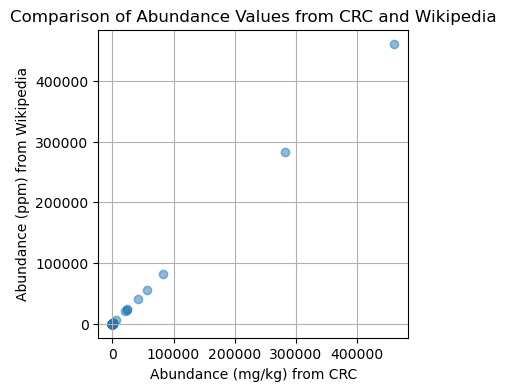

In [140]:
import matplotlib.pyplot as plt
# Create a scatter plot to visualize the relationship between the abundance values from both DataFrames.
# and set size of plot to 4x4 inches.
plt.figure(figsize=(4, 4))
plt.scatter(final_df["crust mg kg-1CRC"], final_df["Abundance (ppm)Wiki"], alpha=0.5)
plt.xlabel("Abundance (mg/kg) from CRC")
plt.ylabel("Abundance (ppm) from Wikipedia")
plt.title("Comparison of Abundance Values from CRC and Wikipedia")
plt.grid(True)
plt.show()

### A Log-Log Plot

the plot above reveals that most of the data is for very small relative abundances. ten elements make up 99% of the crust. the other seventy or more in the data set are present in small amounts. To see all the data better let us use a log scale.

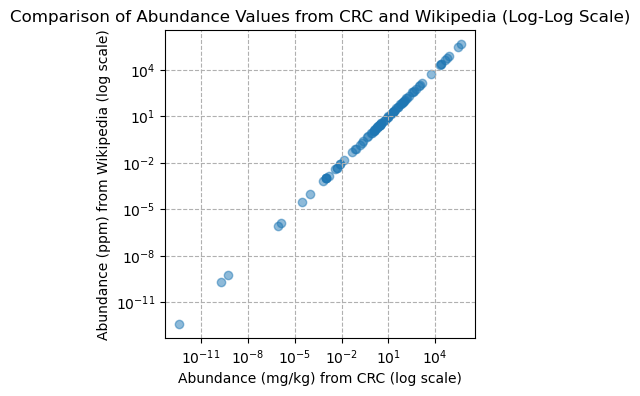

In [141]:
# Make a log-log plot to better visualize the relationship between the abundance values from both DataFrames, especially for elements with low abundance.
plt.figure(figsize=(4, 4))
plt.scatter(final_df["crust mg kg-1CRC"], final_df["Abundance (ppm)Wiki"], alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Abundance (mg/kg) from CRC (log scale)")
plt.ylabel("Abundance (ppm) from Wikipedia (log scale)")
plt.title("Comparison of Abundance Values from CRC and Wikipedia (Log-Log Scale)")
plt.grid(True, which="both", ls="--")
plt.show()

## Reproducing the Elemental Abundance Plot 

We can sue either data set, now that we know they are identical. I will plot abundance vs atomic number. Will we get something similar to the plot from wikipedia?


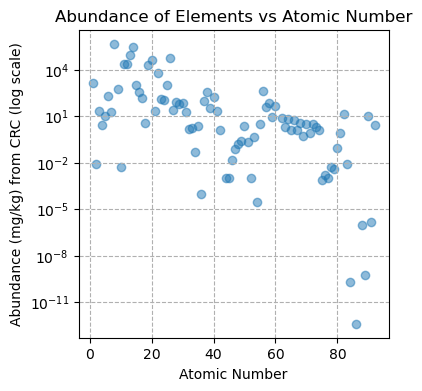

In [142]:
# plot abundance vs number to see if there is any relationship between the abundance of an element 
# and its atomic number.
plt.figure(figsize=(4, 4))
plt.scatter(final_df["numberCRC"], final_df["crust mg kg-1CRC"], alpha=0.5)
plt.xscale("linear")
plt.yscale("log")
plt.xlabel("Atomic Number")
plt.ylabel("Abundance (mg/kg) from CRC (log scale)")
plt.title("Abundance of Elements vs Atomic Number")
plt.grid(True, which="both", ls="--")
plt.show()

The above plot does not resemble the Wikipedia plot. It includes more elements. I could have the plot tool display the atomic symbols as labels but they would all be on top of each other. So I will make an interactive plot using a different plotting tool. Mouseover the plot below to interogate each point.

In [143]:
# make the plot again but make it interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

final_df = final_df.sort_values("numberCRC") # Sort the DataFrame by the atomic number column in ascending order to ensure that the lines in the plot connect the points in the correct order.

fig = px.scatter(final_df, 
                x="numberCRC", 
                y="crust mg kg-1CRC",
                width=500, 
                height=500, 
                hover_data=["nameCRC"], 
                log_y=True, 
                title="Abundance of Elements vs Atomic Number", 
                labels={"numberCRC": "Atomic Number", "crust mg kg-1CRC": "Abundance (mg/kg) from CRC (log scale)"})


fig.update_traces(
    customdata=final_df[["nameCRC"]],
    hovertemplate=
    "Atomic #: %{x}<br>" +
    "Abundance: %{y}<br>" +
    "Sample: %{customdata[0]}<extra></extra>"
)

fig.update_traces(
    mode="lines+markers",
    marker=dict(size=5, color="black", opacity=1,),
    line=dict(
        color="black",
        width=2
    ),
    selector=dict(mode="markers")
)
fig.write_html("plot_abundance.html", include_plotlyjs="cdn")
fig.show()  

 



```{raw} html
:file: plot_abundance.html
```

[Click here to See Interactive Plot](plot_abundance.html) (just in case it doesn't appear on this page).

We see that our plot includes the noble gasses, which are very rare on Earth and some of the higher mass highly radiactive elements that are also very rare (they have decayed away).



### A Close Copy of the Wikipedia Plot

By editing the data set to remove elements that were not included in the wikipedia plot and plotting the data in groups I can make a plot that will be as similar as possible to the plot presented on Wikipedia. The code below may look busy, but it just a series of commands give in order. Its not a real program. Also it was written by MS Copilot. I don't know how to program, but I am willing to monkey around. 

Compare my plot with the literture version, which I will reproduce just below asa well.

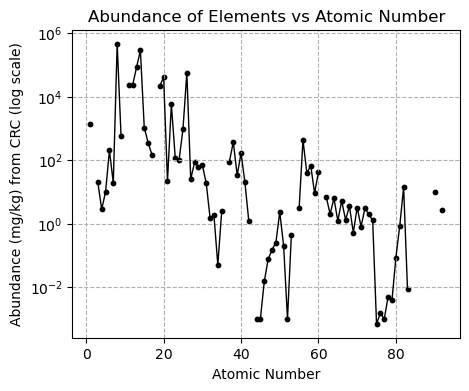

In [166]:
size = 10
color = 'black'
plt.figure(figsize=(5, 4))

# List of elements to plot. excludes noble gases and unstable radioactive elements.
group_list = [[1,1], [3,9], [11,17], [19,35], [37,42], [44,53], [55,60], [62,83], [90,90], [92,92],] 
for group in group_list:
    group = list(range(group[0], group[1] + 1)) # Create a list of atomic numbers from bounds (inclusive) 
    # choose x values where atomic number is in group list and y values where atomic number is in group list
    x = final_df[final_df_edit["numberCRC"].isin(group)]["numberCRC"]
    y = final_df[final_df_edit["numberCRC"].isin(group)]["crust mg kg-1CRC"] 

    plt.scatter(x, y, color=color, alpha=1, s=size)
    plt.plot(x, y, color="black", linewidth=1) # Add a line connecting the points in the scatter plot to better visualize the trend in the data.

plt.xscale("linear")
plt.yscale("log")
plt.xlabel("Atomic Number")
plt.ylabel("Abundance (mg/kg) from CRC (log scale)")
plt.title("Abundance of Elements vs Atomic Number")
plt.grid(True, which="both", ls="--")
plt.show()

```{figure} images/Elemental_abundances.svg.png
:alt: Elemental abundance on Earth (wikipedia)
:width: 500px
:class: align-left

The plot presented in the Remick, 2023 paper and on WikiPedia.
```



### A Confession

The plot above is very similar to the wikipedia plot, but has some significant differences. Observe elements 44, 45 and 46 (ruthenium, rhodium and palladium) in both plots and you will see what I mean. Remek et al. present a plot sourced from Wikipedia but state that they are using data from the CRC handbook. We see here that the data set used for the wikipedia plot is not the same as the data set in the CRC handbook. The data used in the Wikipedia plot is from the paper below. The wikipedia plot is presented there and we have found its original source. However, no data tables are presented.

> Haxel, G.B.; Hedrick, J.B.; Orris, G.J., "Rare Earth Elements—Critical Resources for High Technology: USGS Fact Sheet 087-02". [https://pubs.usgs.gov/fs/2002/fs087-02/](https://pubs.usgs.gov/fs/2002/fs087-02/). Accessed April 30, 2026.
 
Remek et al. state that they will use the CRC data in their analysis and discussion. I misinterpretted that as them saying that that data was used to make the plot. I went through this whole rabbit hole trying to confirm if the CRC data set would give the plot (close, but not exact) and could have saved myself some work if I had read the figure legend more carefully. 

## More
I also discovered a wealth of data about the elements on the wikipedia data page for elemental abundance. Wikipedia has collected data from many sources.
[https://en.wikipedia.org/wiki/Abundances_of_the_elements_(data_page)](https://en.wikipedia.org/wiki/Abundances_of_the_elements_(data_page))

I cut and pasted the HTML data tables from Wikipedia for 
Kaye and Laby

[https://web.archive.org/web/20190518224615/](https://web.archive.org/web/20190518224615/)

[http://www.kayelaby.npl.co.uk/chemistry/3_1/3_1_3.html](http://www.kayelaby.npl.co.uk/chemistry/3_1/3_1_3.html)

[https://web.archive.org/web/20190506031327/http://www.kayelaby.npl.co.uk/](https://web.archive.org/web/20190506031327/http://www.kayelaby.npl.co.uk/)


Hamilton, E.I., "Geobiocoenosis: The chemical elements and relative abundance in biotic and abiotic systems." Sci. Total Environ., 1988, 71, 253–267. [https://doi.org/10.1016/0048-9697(88)90197-0](https://doi.org/10.1016/0048-9697(88)90197-0) 

[https://en.wikipedia.org/wiki/Composition_of_the_human_body](https://en.wikipedia.org/wiki/Composition_of_the_human_body)

[https://bionumbers.hms.harvard.edu/search.aspx?task=searchbytrmorg&log=y&trm=Biosphere](https://bionumbers.hms.harvard.edu/search.aspx?task=searchbytrmorg&log=y&trm=Biosphere)
These numbers alegedly from John Harte, Consider a Spherical Cow: A Course in Environmental Problem Solving, Berkeley. 1988. University Science Books p.243 VIII. The Elements table 1 978-0935702583
Borrow it from [https://archive.org/details/considerspherica00hart](https://archive.org/details/considerspherica00hart)
In UPEI Library at QH541.15.M34 H37 1985

Fun fact - Human moeclulat formula
[https://bionumbers.hms.harvard.edu/bionumber.aspx?id=111244&ver=4&trm=elemental+abundance&org=](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=111244&ver=4&trm=elemental+abundance&org=)

d